"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

**The data set includes information about:**

Customers who left within the last month – the column is called Churn

Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

Demographic info about customers – gender, age range, and if they have partners and dependents

In [405]:
import pandas as pd

churn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)
churn

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [406]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [407]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors='coerce')

In [408]:
for col in churn.columns:
    if churn[col].dtype != 'int64' and churn[col].dtype != 'float64':
        print(f'{col} : {churn[col].unique()}')

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [409]:
cols = churn.columns[churn.apply(lambda col: col.astype(str).str.contains('Yes|No').any())]
# cols_with_yes_no = list(cols[:3]) + list(cols[-2:])
churn[cols].nunique()

Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
PaperlessBilling    2
Churn               2
dtype: int64

In [410]:
cols

Index(['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'Churn'],
      dtype='object')

In [411]:
churn

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [412]:
# churn[cols_with_yes_no] = churn[cols_with_yes_no].astype(bool)

In [413]:
churn.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [414]:
nan = churn[churn['TotalCharges'].isnull()].index
churn.drop(nan, inplace=True)

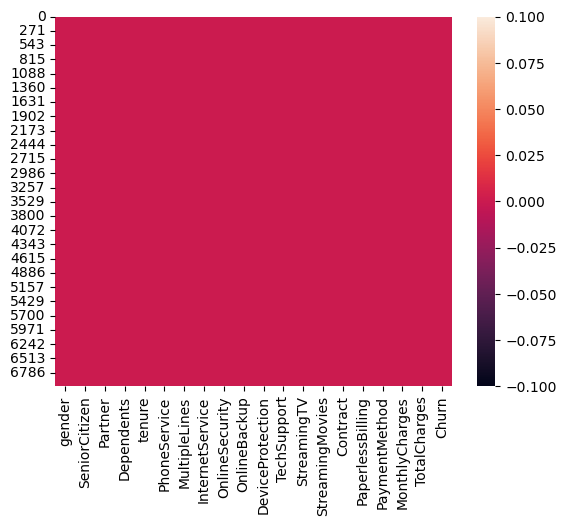

In [415]:
import seaborn as sns

sns.heatmap(churn.isnull());

In [416]:
churn.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


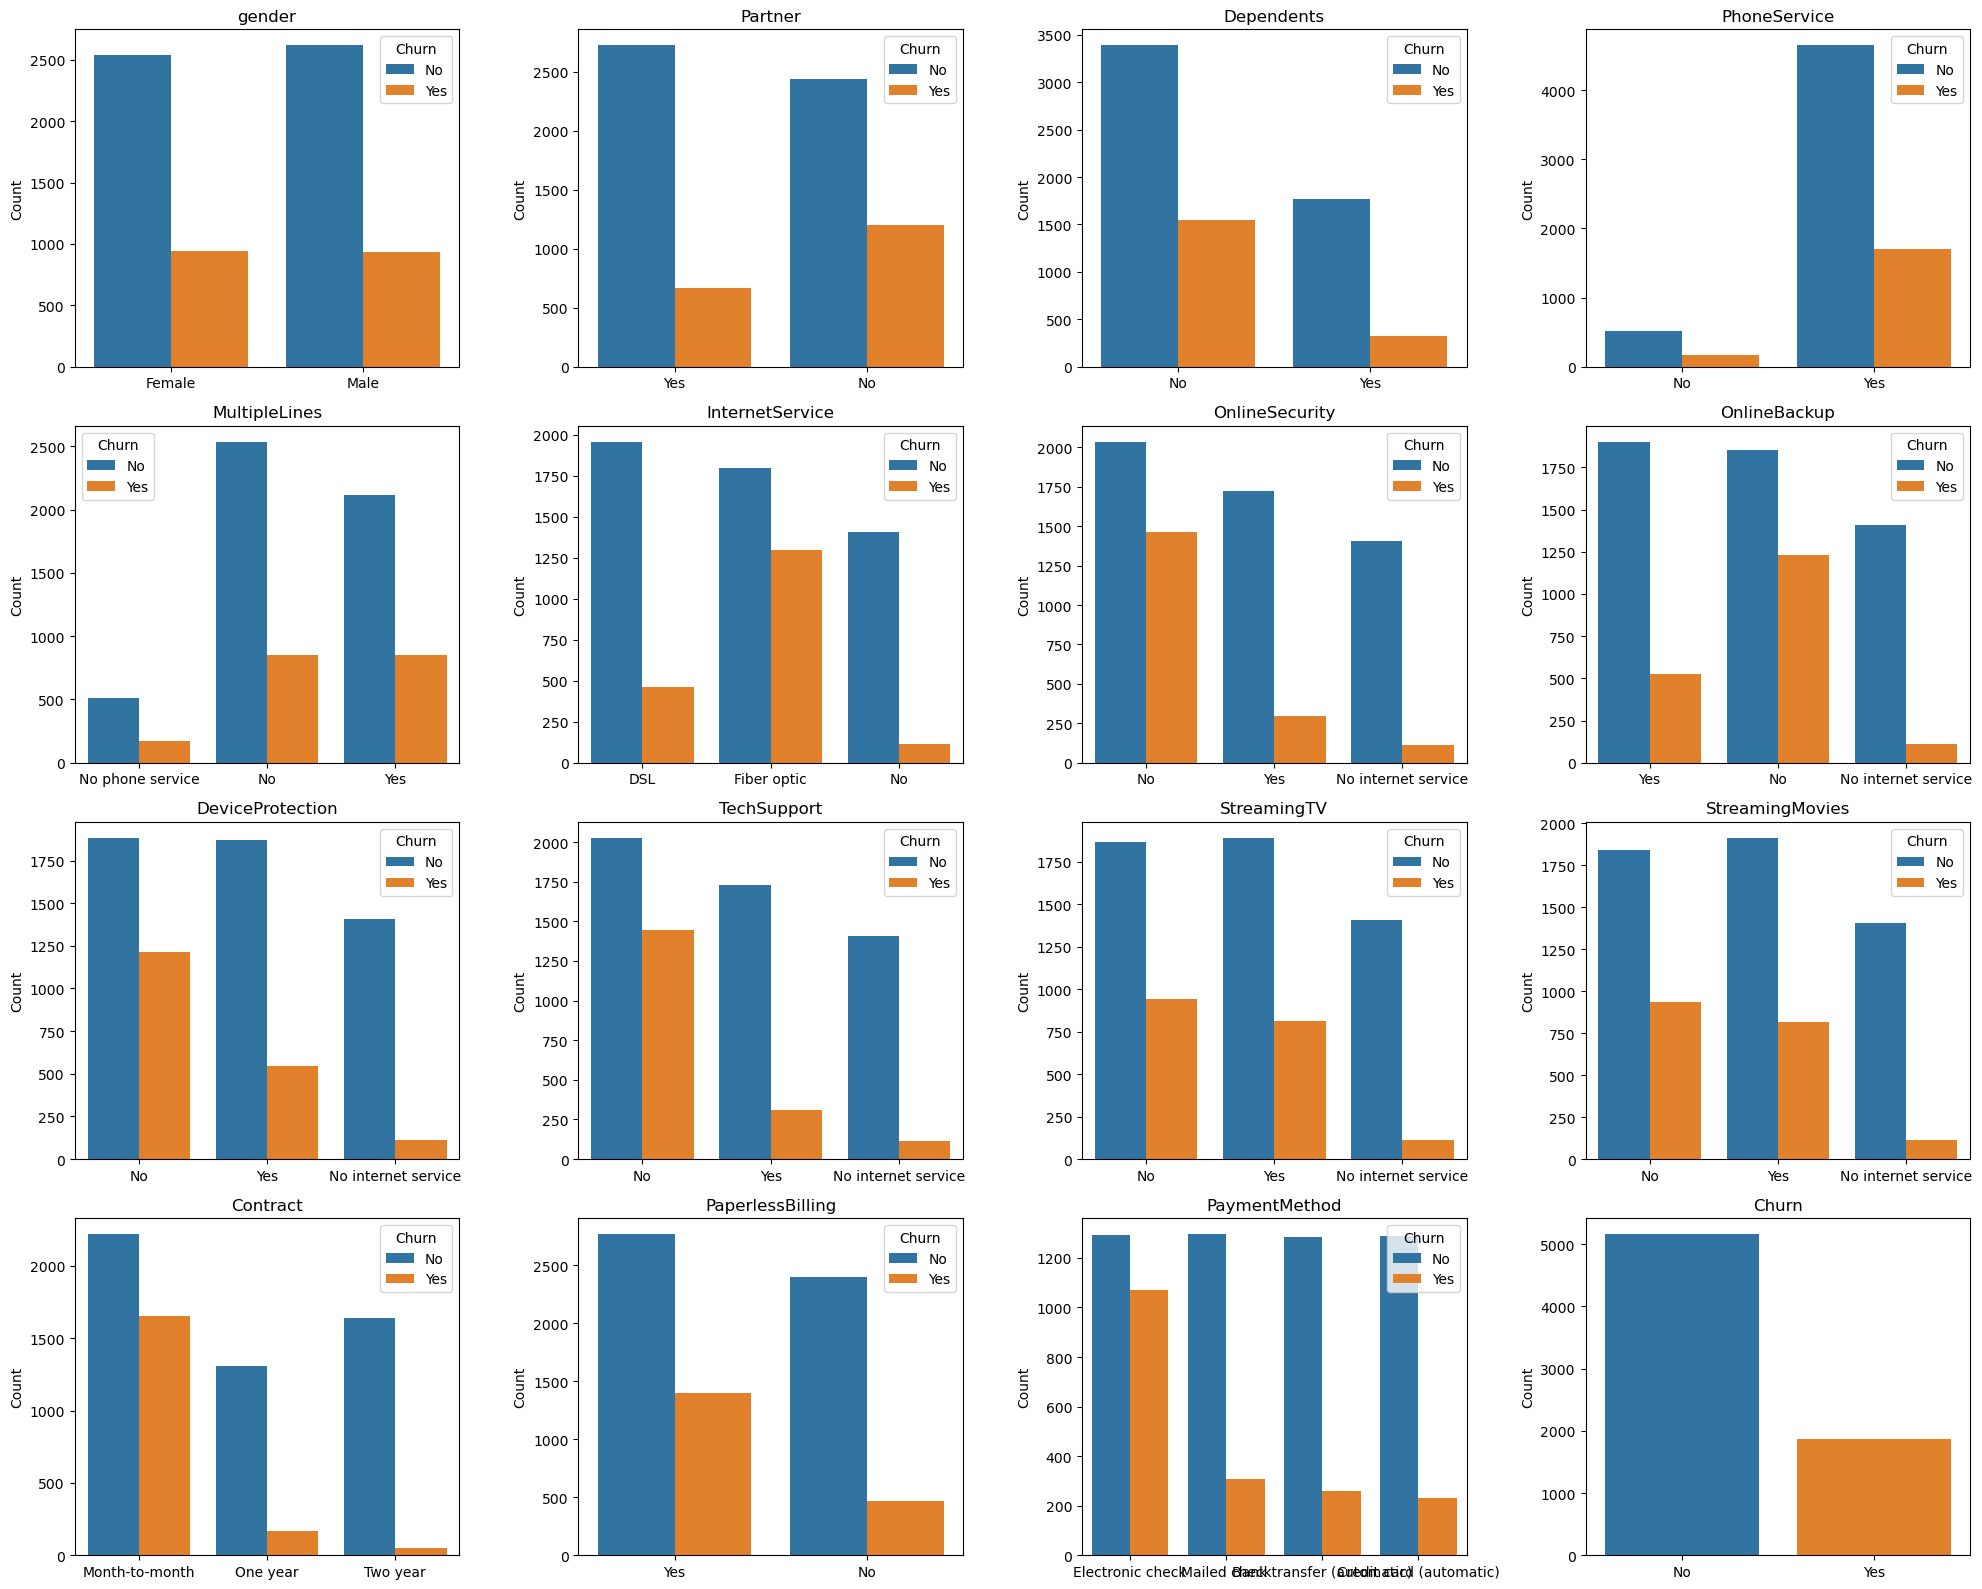

In [417]:
import matplotlib.pyplot as plt
import math

cols = churn.select_dtypes(exclude='number').columns
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() # Flatten to 1D array for easy indexing

for i, col in enumerate(cols):
    sns.countplot(data=churn, x=col, hue='Churn', ax=axes[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{col}')
    # axes[i].tick_params(axis='x', rotation=8)

# Hide extra axes if any
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

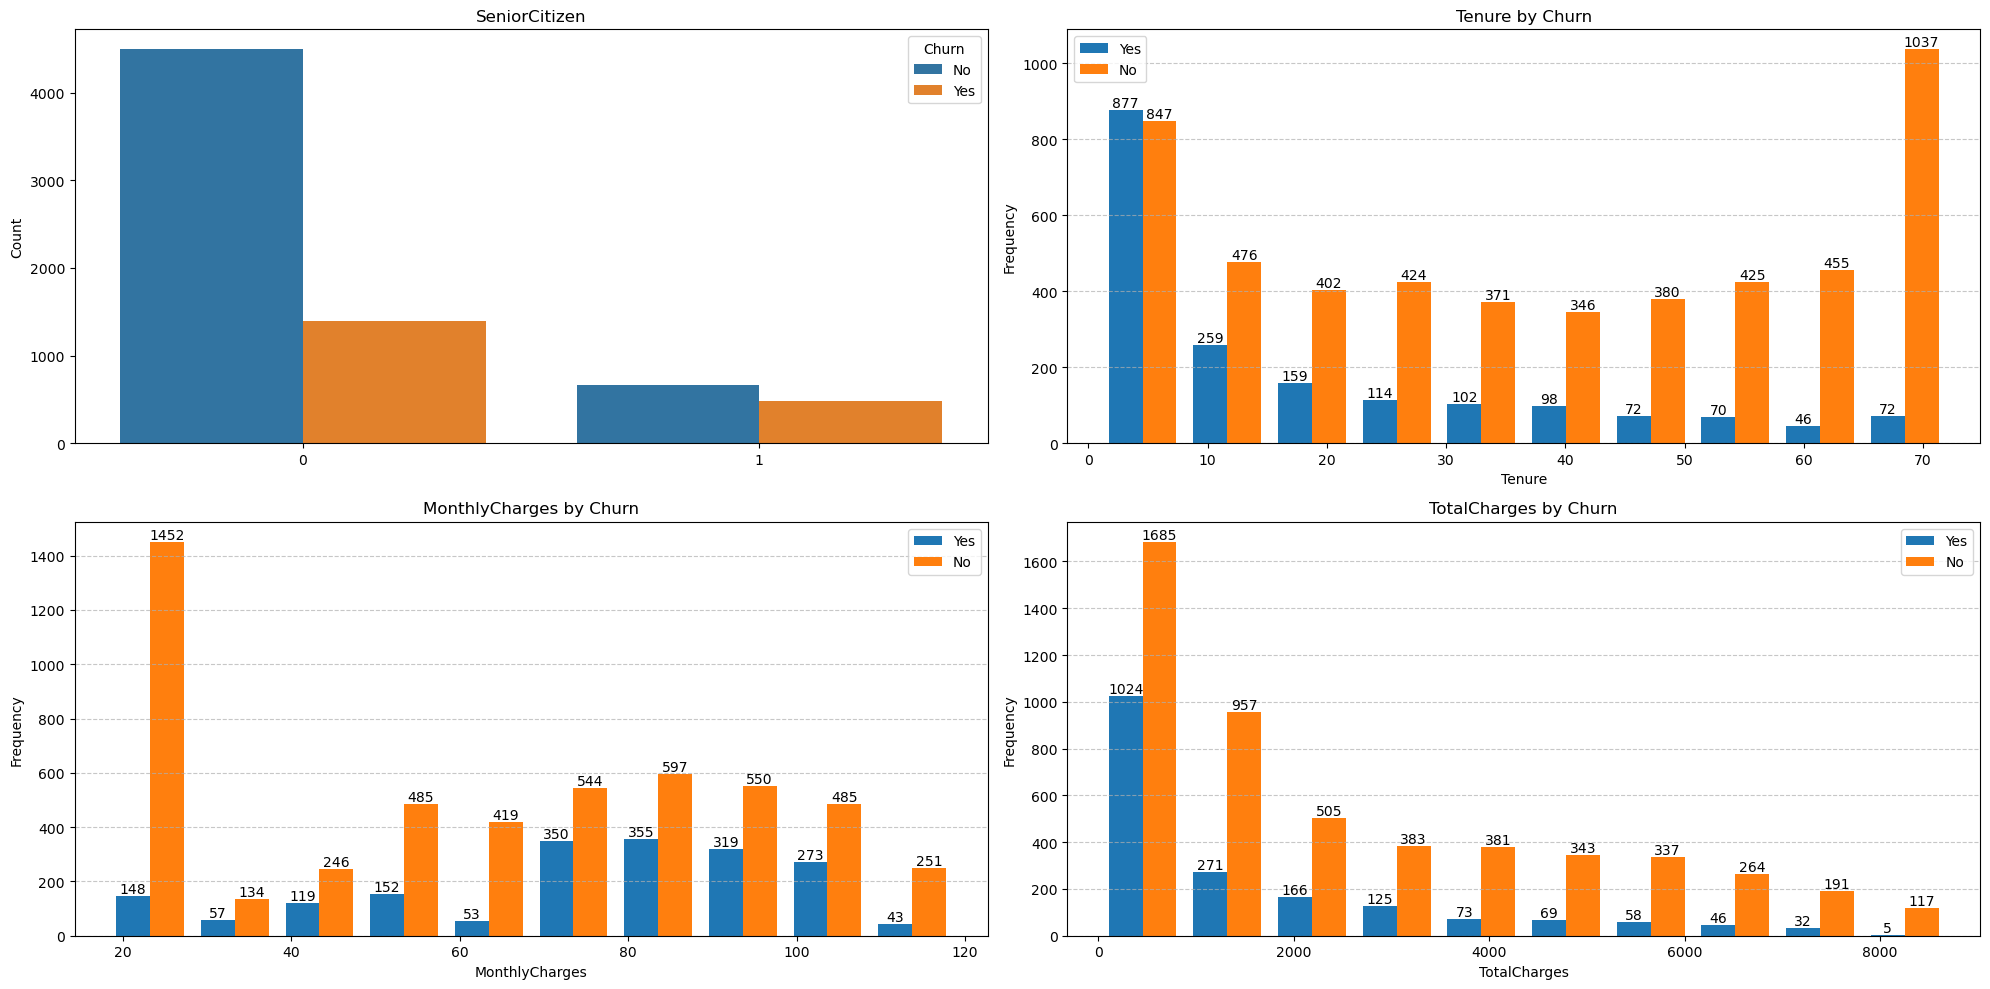

In [418]:
cols = ['SeniorCitizen', 'tenure']

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

# Plot 1: countplot of SeniorCitizen
sns.countplot(data=churn, x=cols[0], hue='Churn', ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].set_title(cols[0])

# Plot 2: histogram of tenure
churned = churn[churn['Churn'] == 'Yes']
not_churned = churn[churn['Churn'] == 'No']

axes[1].hist([churned['tenure'], not_churned['tenure']], bins=10, label=['Yes', 'No'])
axes[1].set_title('Tenure by Churn')
axes[1].set_xlabel('Tenure')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for rect in axes[1].patches:
    height = rect.get_height()
    axes[1].text(rect.get_x() + rect.get_width() / 2, height, int(height), ha='center', va='bottom')

# Plot 3: histogram of monthly charges
axes[2].hist([churned['MonthlyCharges'], not_churned['MonthlyCharges']], bins=10, label=['Yes', 'No'])
axes[2].set_title('MonthlyCharges by Churn')
axes[2].set_xlabel('MonthlyCharges')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

for rect in axes[2].patches:
    height = rect.get_height()
    axes[2].text(rect.get_x() + rect.get_width() / 2, height, int(height), ha='center', va='bottom')

# Plot 4: histogram of total charges
axes[3].hist([churned['TotalCharges'], not_churned['TotalCharges']], bins=10, label=['Yes', 'No'])
axes[3].set_title('TotalCharges by Churn')
axes[3].set_xlabel('TotalCharges')
axes[3].set_ylabel('Frequency')
axes[3].legend()
axes[3].grid(axis='y', linestyle='--', alpha=0.7)

for rect in axes[3].patches:
    height = rect.get_height()
    axes[3].text(rect.get_x() + rect.get_width() / 2, height, int(height), ha='center', va='bottom')

plt.tight_layout()
plt.show()

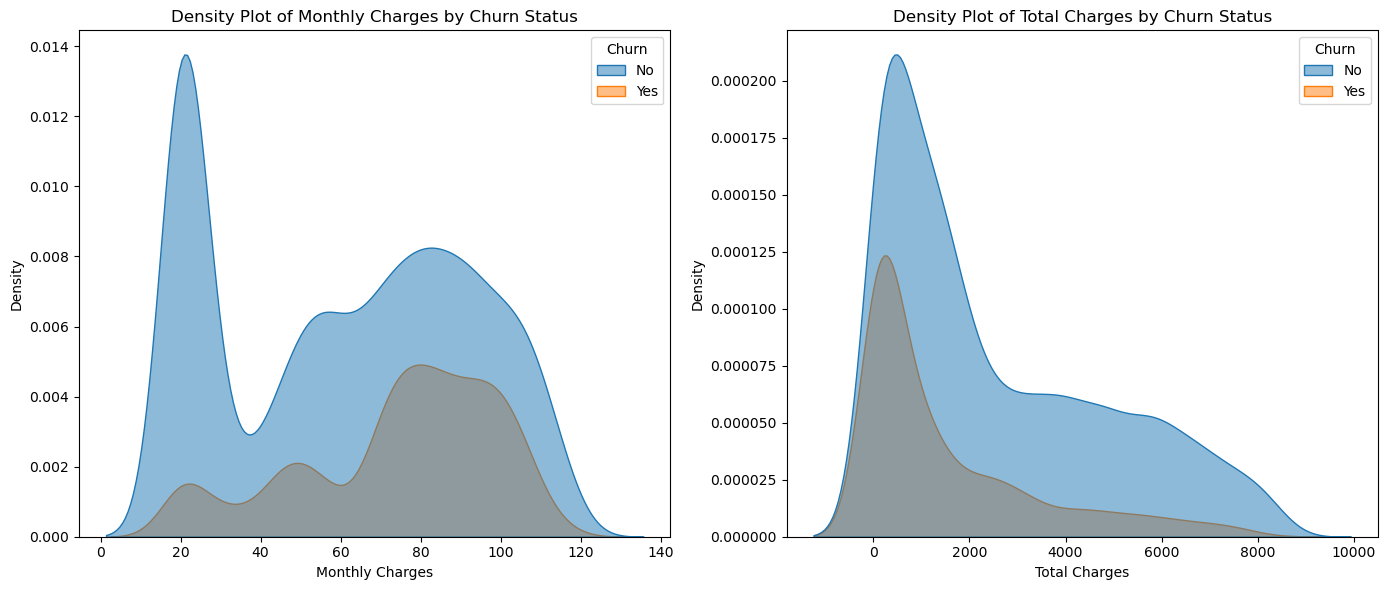

In [419]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Monthly Charges
sns.kdeplot(data=churn, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Density Plot of Monthly Charges by Churn Status')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Density')

# Plot for Total Charges
sns.kdeplot(data=churn, x="TotalCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Density Plot of Total Charges by Churn Status')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [420]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_cols = churn.select_dtypes(include=['category', 'object']).columns

# Apply OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)  # Setting drop='first' to avoid multicollinearity
encoded_data = encoder.fit_transform(churn[categorical_cols])

# Create a DataFrame from the encoded data
encoded_churn = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))

# Drop the original categorical columns from the DataFrame
churn.drop(columns=categorical_cols, inplace=True)

# Reset index of the DataFrame
churn.reset_index(drop=True, inplace=True)

# Concatenate the original DataFrame with the encoded DataFrame
churn = pd.concat([churn, encoded_churn], axis=1)

In [421]:
churn.drop('Churn_No', axis=1, inplace=True)

In [422]:
churn.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

In [423]:
from sklearn.model_selection import train_test_split

# split data into X and y
X = churn.drop('Churn', axis=1)
y = churn['Churn']
# data into train and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [424]:
# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import GridSearchCV, cross_val_score
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),
    ('Support Vector Machine', SVC(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__gamma': ['scale', 'auto']}),
    ('Logistic Regression', LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear'),
        {'model__C': [0.1, 1, 10],
         'model__penalty': ['l1', 'l2']}),  # Fixed: Changed solver to 'liblinear'
    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'model__max_depth': [None, 10, 20],
         'model__min_samples_split': [2, 5, 10]}),
    ('Ada Boost', AdaBoostClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),
    ('XG Boost', XGBClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),
    ('Naive Bayes', GaussianNB(), {})
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),  # Feature Scaling
        ('model', model)
    ])

    # Hyperparameter tuning using GridSearchCV
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2)
        grid_search.fit(X_train, y_train)
        pipeline = grid_search.best_estimator_

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

    # Convert the list to a DataFrame
    scores_df = pd.DataFrame(model_scores)
    # Print the performance metrics
    print("Model:", name)
    print("Test Accuracy:", round(accuracy, 3))
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the overall best model
print("Best Model:")
print("Test Accuracy:", best_accuracy)
print("Model Pipeline:", best_model, "with accuracy", round(best_accuracy, 3))

Model: Random Forest
Test Accuracy: 0.789

Model: Gradient Boosting
Test Accuracy: 0.796

Model: Support Vector Machine
Test Accuracy: 0.738

Model: Logistic Regression
Test Accuracy: 0.743

Model: K-Nearest Neighbors
Test Accuracy: 0.762

Model: Decision Tree
Test Accuracy: 0.763

Model: Ada Boost
Test Accuracy: 0.794

Model: XG Boost
Test Accuracy: 0.791

Model: Naive Bayes
Test Accuracy: 0.687

Best Model:
Test Accuracy: 0.7960199004975125
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            random_state=42))]) with accuracy 0.796


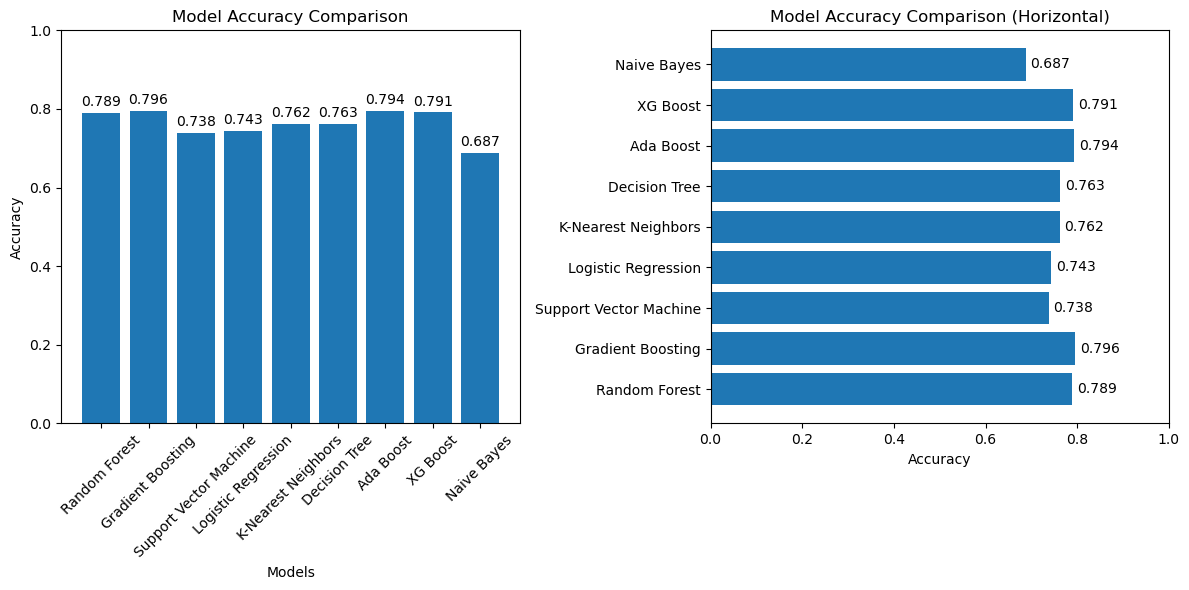

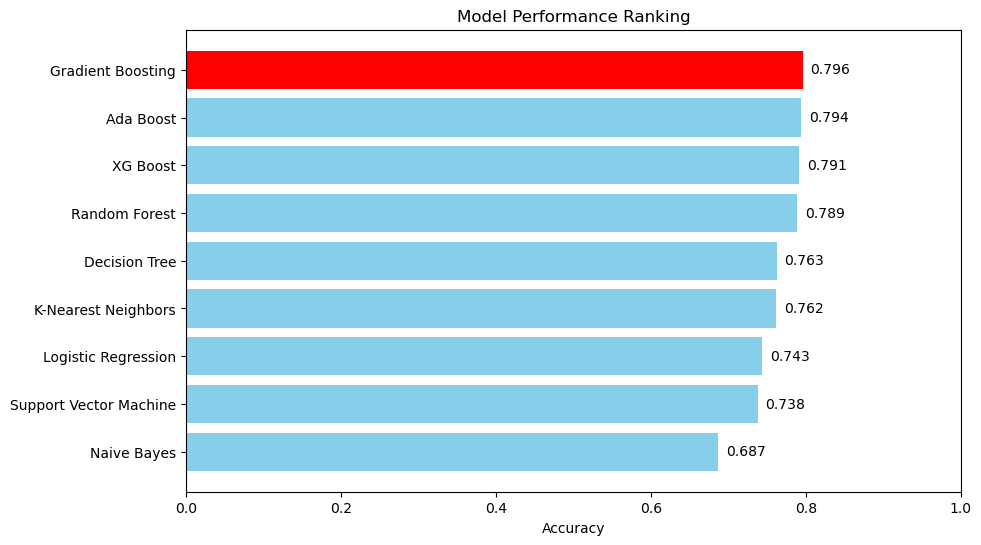

In [425]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Assuming you have model_scores list from your previous code
# Convert to DataFrame if not already done
scores_df = pd.DataFrame(model_scores)

# 1. Bar Plot of Model Accuracies
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(scores_df['Model'], scores_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')

# 2. Horizontal Bar Plot (easier to read model names)
plt.subplot(1, 2, 2)
plt.barh(scores_df['Model'], scores_df['Accuracy'])
plt.title('Model Accuracy Comparison (Horizontal)')
plt.xlabel('Accuracy')
plt.xlim(0, 1)

# Add value labels
for i, v in enumerate(scores_df['Accuracy']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# 3. Sorted Bar Plot (Best to Worst)
plt.figure(figsize=(10, 6))
scores_sorted = scores_df.sort_values('Accuracy', ascending=True)
colors = ['red' if x == scores_sorted['Accuracy'].max() else 'skyblue' 
          for x in scores_sorted['Accuracy']]
bars = plt.barh(scores_sorted['Model'], scores_sorted['Accuracy'], color=colors)
plt.title('Model Performance Ranking')
plt.xlabel('Accuracy')
plt.xlim(0, 1)

# Add value labels
for i, v in enumerate(scores_sorted['Accuracy']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.show()

Comprehensive Model Evaluation:
Accuracy: 0.806
Balanced Accuracy: 0.818
F1 Score: 0.783

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.99      0.83       541
         1.0       0.98      0.65      0.78       625

    accuracy                           0.81      1166
   macro avg       0.85      0.82      0.80      1166
weighted avg       0.85      0.81      0.80      1166



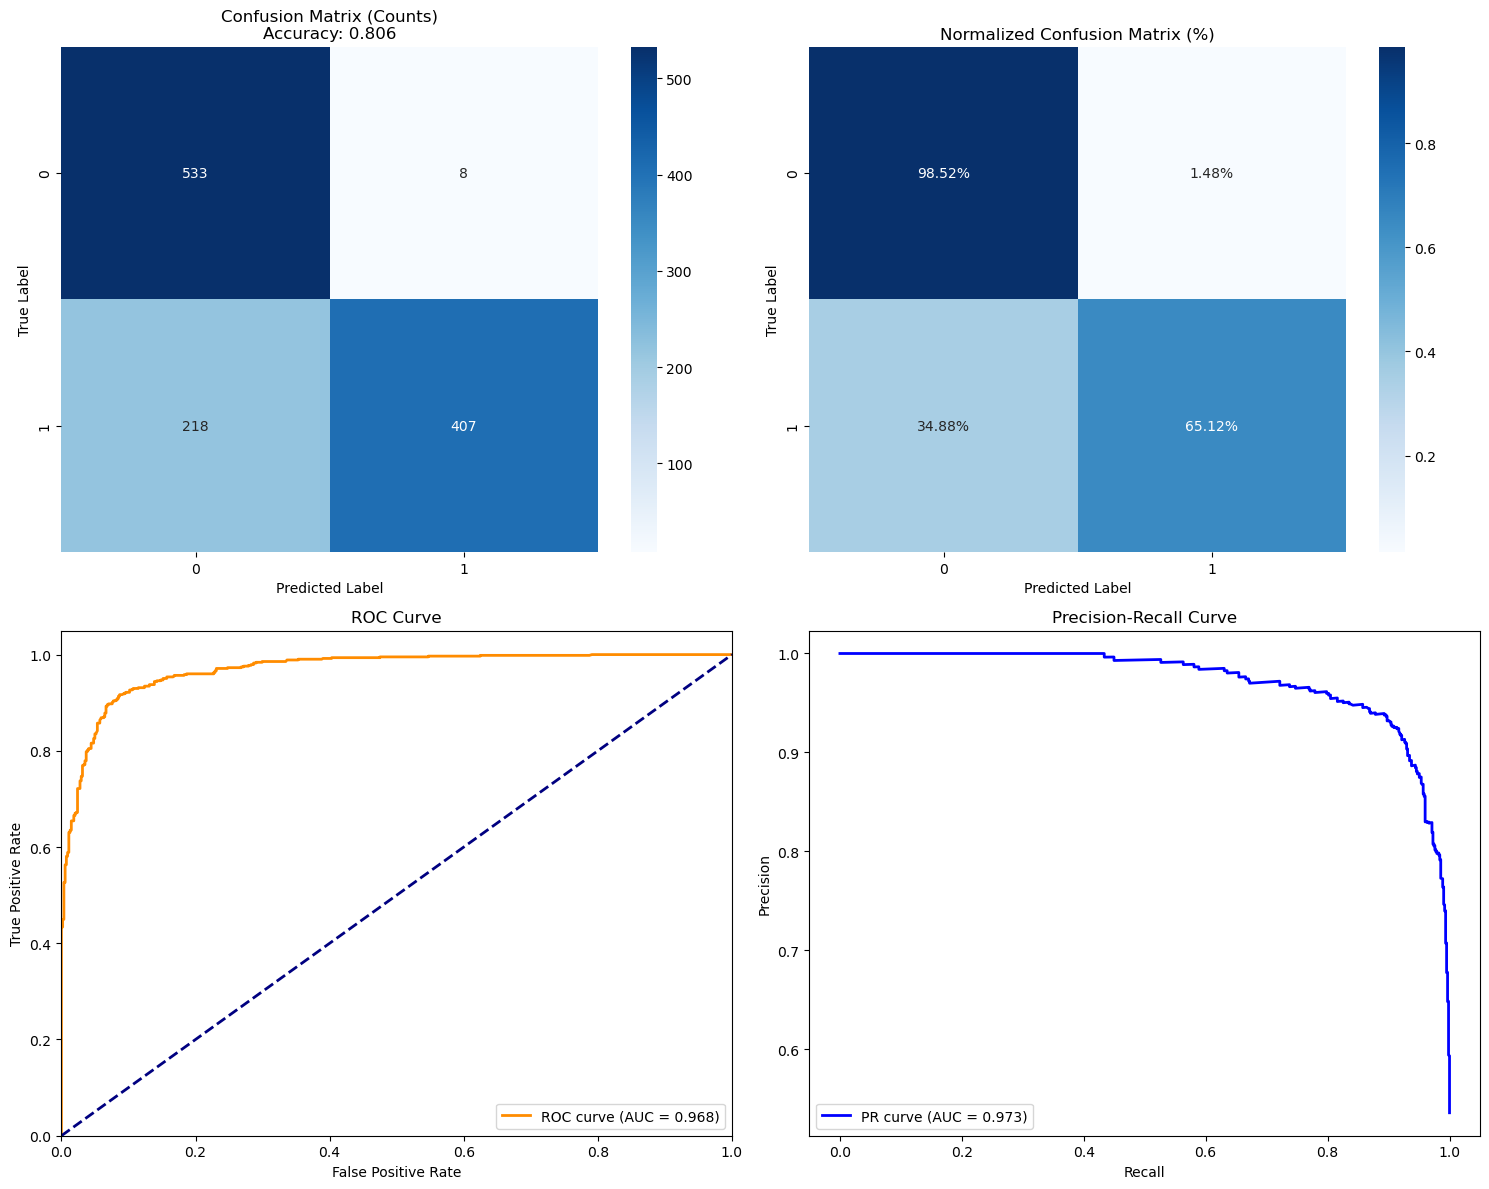


Class Distribution Analysis:
Training set:
  Class 0.0: 2091 samples (44.9%)
  Class 1.0: 2569 samples (55.1%)
Test set:
  Class 0.0: 541 samples (46.4%)
  Class 1.0: 625 samples (53.6%)

Per-Class Performance:
Class 0 (Negative):
  Precision: 0.710
  Recall: 0.985
Class 1 (Positive):
  Precision: 0.981
  Recall: 0.651

Recommendations:
• F1 score is low - check precision/recall trade-off
• Adjust classification threshold based on cost of errors
• Optimal threshold for F1: 0.2 (F1: 0.913)


In [426]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score, f1_score
import numpy as np

# Calculate additional metrics for better evaluation
y_pred_best = best_model.predict(Xr_test)
y_pred_proba = best_model.predict_proba(Xr_test)[:, 1]  # For binary classification

# Multiple evaluation metrics
accuracy = accuracy_score(yr_test, y_pred_best)
balanced_acc = balanced_accuracy_score(yr_test, y_pred_best)
f1 = f1_score(yr_test, y_pred_best)

print("Comprehensive Model Evaluation:")
print("=" * 40)
print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print(f"F1 Score: {f1:.3f}")
print()

# Detailed classification report
print("Classification Report:")
print(classification_report(yr_test, y_pred_best))

# Create subplots for comprehensive analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix with percentages
cm = confusion_matrix(yr_test, y_pred_best)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title(f'Confusion Matrix (Counts)\nAccuracy: {accuracy:.3f}')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[0,1])
axes[0,1].set_title('Normalized Confusion Matrix (%)')
axes[0,1].set_ylabel('True Label')
axes[0,1].set_xlabel('Predicted Label')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(yr_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1,0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1,0].set_xlim([0.0, 1.0])
axes[1,0].set_ylim([0.0, 1.05])
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curve')
axes[1,0].legend(loc="lower right")

# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(yr_test, y_pred_proba)
pr_auc = auc(recall, precision)

axes[1,1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curve')
axes[1,1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# Class distribution analysis
print("\nClass Distribution Analysis:")
print("=" * 30)
unique_train, counts_train = np.unique(yr_train, return_counts=True)
unique_test, counts_test = np.unique(yr_test, return_counts=True)

print("Training set:")
for cls, count in zip(unique_train, counts_train):
    print(f"  Class {cls}: {count} samples ({count/len(yr_train)*100:.1f}%)")

print("Test set:")
for cls, count in zip(unique_test, counts_test):
    print(f"  Class {cls}: {count} samples ({count/len(yr_test)*100:.1f}%)")

# Performance per class
tn, fp, fn, tp = cm.ravel()
print(f"\nPer-Class Performance:")
print("=" * 25)
print(f"Class 0 (Negative):")
print(f"  Precision: {tn/(tn+fn):.3f}")
print(f"  Recall: {tn/(tn+fp):.3f}")
print(f"Class 1 (Positive):")
print(f"  Precision: {tp/(tp+fp):.3f}")
print(f"  Recall: {tp/(tp+fn):.3f}")

# Recommendations
print(f"\nRecommendations:")
print("=" * 20)
if balanced_acc < accuracy:
    print("• Model shows class imbalance bias")
    print("• Consider using balanced_accuracy_score as primary metric")
if f1 < 0.8:
    print("• F1 score is low - check precision/recall trade-off")
if fp > fn or fn > fp:
    print("• Adjust classification threshold based on cost of errors")
    
# Threshold optimization (optional)
thresholds = np.arange(0.1, 1.0, 0.1)
f1_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    f1_thresh = f1_score(yr_test, y_pred_thresh)
    f1_scores.append(f1_thresh)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"• Optimal threshold for F1: {optimal_threshold:.1f} (F1: {max(f1_scores):.3f})")

In [427]:
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from scipy.stats import uniform, randint

# UpSampling
sm = SMOTEENN()
X_res, y_res = sm.fit_resample(X, y)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),
    ('Support Vector Machine', SVC(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__gamma': ['scale', 'auto']}),
    ('Logistic Regression', LogisticRegression(random_state=42, class_weight='balanced', 
                                              solver='liblinear', max_iter=1000),
        {'model__C': [0.1, 1, 10],
         'model__penalty': ['l1', 'l2']}),
    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'model__max_depth': [None, 10, 20],
         'model__min_samples_split': [2, 5, 10]}),
    ('Ada Boost', AdaBoostClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),
    ('XG Boost', XGBClassifier(random_state=42),
        {'model__max_depth': [3, 4, 5],
         'model__learning_rate': [0.01, 0.1, 0.2],
         'model__n_estimators': [100, 200, 300],
         'model__subsample': [0.8, 0.9, 1.0]}),
    ('Naive Bayes', GaussianNB(), {})
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    # Hyperparameter tuning using RandomizedSearchCV for XG Boost
    if name == 'XG Boost' and param_grid:
        random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_grid,
                                          n_iter=20, cv=3, verbose=0, random_state=42, n_jobs=-1)
        random_search.fit(Xr_train, yr_train)
        pipeline = random_search.best_estimator_
    # Hyperparameter tuning using GridSearchCV for other models
    elif param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2, verbose=0)
        grid_search.fit(Xr_train, yr_train)
        pipeline = grid_search.best_estimator_
    else:
        # Fit the pipeline on the training data for models without hyperparameters
        pipeline.fit(Xr_train, yr_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(Xr_test)

    # Calculate accuracy score
    accuracy = accuracy_score(yr_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

    # Print the performance metrics
    print("Model:", name)
    print("Test Accuracy:", round(accuracy, 3))
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Convert the list to a DataFrame
scores_df = pd.DataFrame(model_scores)

# Retrieve the overall best model
print("Best Model:")
print("Test Accuracy:", round(best_accuracy, 3))
print("Model Pipeline:", best_model)

Model: Random Forest
Test Accuracy: 0.961

Model: Gradient Boosting
Test Accuracy: 0.965

Model: Support Vector Machine
Test Accuracy: 0.939

Model: Logistic Regression
Test Accuracy: 0.921

Model: K-Nearest Neighbors
Test Accuracy: 0.894

Model: Decision Tree
Test Accuracy: 0.938

Model: Ada Boost
Test Accuracy: 0.956

Model: XG Boost
Test Accuracy: 0.965

Model: Naive Bayes
Test Accuracy: 0.891

Best Model:
Test Accuracy: 0.965
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])


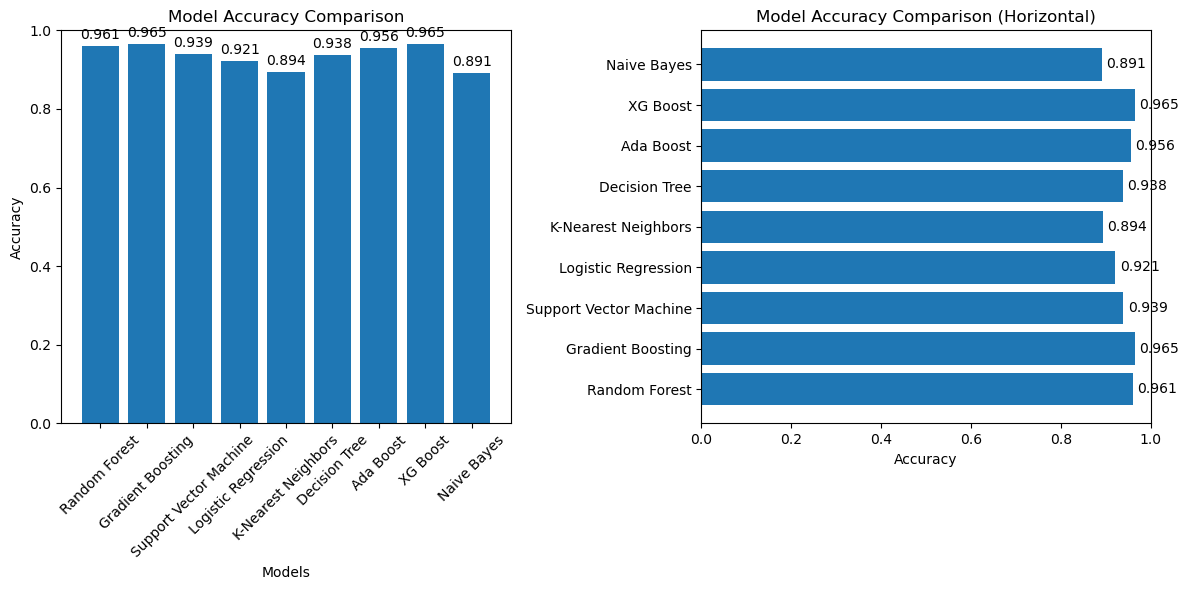

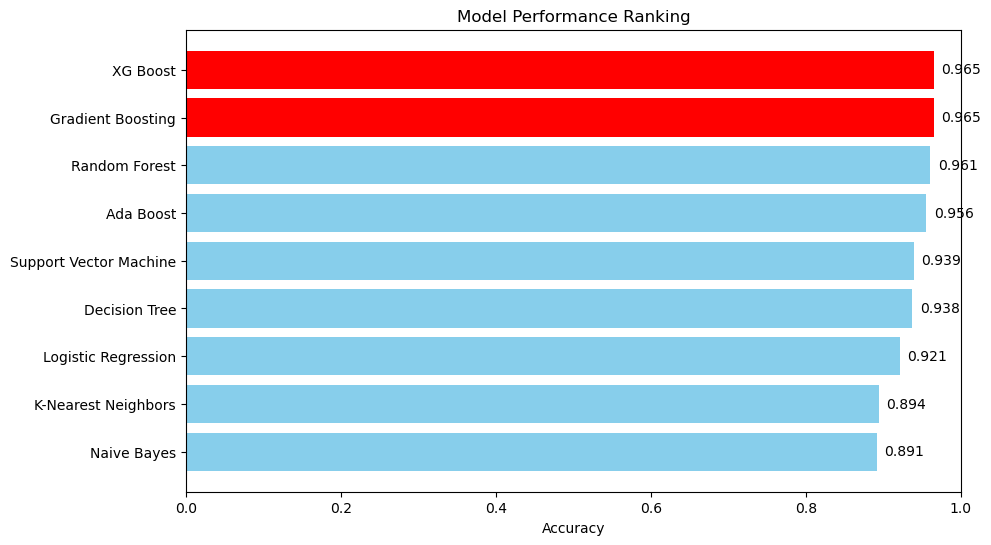

In [428]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Assuming you have model_scores list from your previous code
# Convert to DataFrame if not already done
scores_df = pd.DataFrame(model_scores)

# 1. Bar Plot of Model Accuracies
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(scores_df['Model'], scores_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')

# 2. Horizontal Bar Plot (easier to read model names)
plt.subplot(1, 2, 2)
plt.barh(scores_df['Model'], scores_df['Accuracy'])
plt.title('Model Accuracy Comparison (Horizontal)')
plt.xlabel('Accuracy')
plt.xlim(0, 1)

# Add value labels
for i, v in enumerate(scores_df['Accuracy']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# 3. Sorted Bar Plot (Best to Worst)
plt.figure(figsize=(10, 6))
scores_sorted = scores_df.sort_values('Accuracy', ascending=True)
colors = ['red' if x == scores_sorted['Accuracy'].max() else 'skyblue' 
          for x in scores_sorted['Accuracy']]
bars = plt.barh(scores_sorted['Model'], scores_sorted['Accuracy'], color=colors)
plt.title('Model Performance Ranking')
plt.xlabel('Accuracy')
plt.xlim(0, 1)

# Add value labels
for i, v in enumerate(scores_sorted['Accuracy']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.show()


Comprehensive Model Evaluation:
Accuracy: 0.965
Balanced Accuracy: 0.964
F1 Score: 0.968

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       544
         1.0       0.96      0.98      0.97       625

    accuracy                           0.96      1169
   macro avg       0.97      0.96      0.96      1169
weighted avg       0.97      0.96      0.96      1169



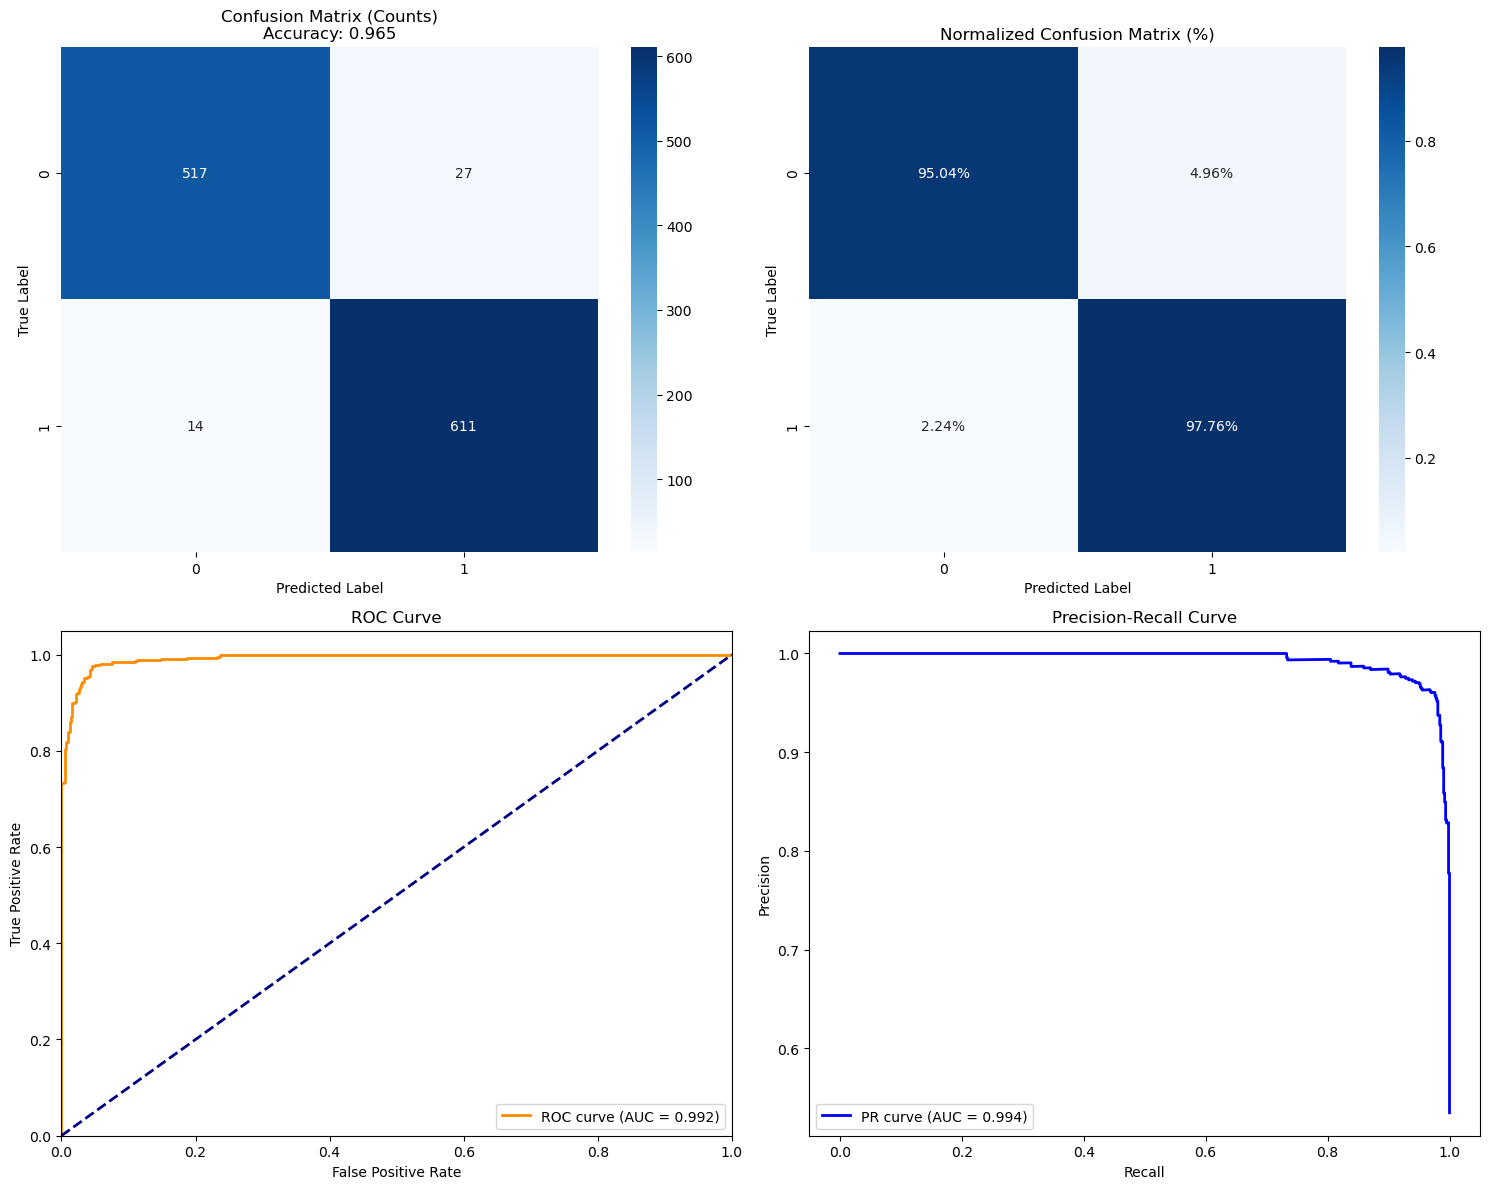


Class Distribution Analysis:
Training set:
  Class 0.0: 2100 samples (44.9%)
  Class 1.0: 2574 samples (55.1%)
Test set:
  Class 0.0: 544 samples (46.5%)
  Class 1.0: 625 samples (53.5%)

Per-Class Performance:
Class 0 (Negative):
  Precision: 0.974
  Recall: 0.950
Class 1 (Positive):
  Precision: 0.958
  Recall: 0.978

Recommendations:
• Model shows class imbalance bias
• Consider using balanced_accuracy_score as primary metric
• Adjust classification threshold based on cost of errors
• Optimal threshold for F1: 0.5 (F1: 0.968)


In [429]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score, f1_score
import numpy as np

# Calculate additional metrics for better evaluation
y_pred_best = best_model.predict(Xr_test)
y_pred_proba = best_model.predict_proba(Xr_test)[:, 1]  # For binary classification

# Multiple evaluation metrics
accuracy = accuracy_score(yr_test, y_pred_best)
balanced_acc = balanced_accuracy_score(yr_test, y_pred_best)
f1 = f1_score(yr_test, y_pred_best)

print("Comprehensive Model Evaluation:")
print("=" * 40)
print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print(f"F1 Score: {f1:.3f}")
print()

# Detailed classification report
print("Classification Report:")
print(classification_report(yr_test, y_pred_best))

# Create subplots for comprehensive analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix with percentages
cm = confusion_matrix(yr_test, y_pred_best)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title(f'Confusion Matrix (Counts)\nAccuracy: {accuracy:.3f}')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[0,1])
axes[0,1].set_title('Normalized Confusion Matrix (%)')
axes[0,1].set_ylabel('True Label')
axes[0,1].set_xlabel('Predicted Label')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(yr_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1,0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1,0].set_xlim([0.0, 1.0])
axes[1,0].set_ylim([0.0, 1.05])
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curve')
axes[1,0].legend(loc="lower right")

# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(yr_test, y_pred_proba)
pr_auc = auc(recall, precision)

axes[1,1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curve')
axes[1,1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# Class distribution analysis
print("\nClass Distribution Analysis:")
print("=" * 30)
unique_train, counts_train = np.unique(yr_train, return_counts=True)
unique_test, counts_test = np.unique(yr_test, return_counts=True)

print("Training set:")
for cls, count in zip(unique_train, counts_train):
    print(f"  Class {cls}: {count} samples ({count/len(yr_train)*100:.1f}%)")

print("Test set:")
for cls, count in zip(unique_test, counts_test):
    print(f"  Class {cls}: {count} samples ({count/len(yr_test)*100:.1f}%)")

# Performance per class
tn, fp, fn, tp = cm.ravel()
print(f"\nPer-Class Performance:")
print("=" * 25)
print(f"Class 0 (Negative):")
print(f"  Precision: {tn/(tn+fn):.3f}")
print(f"  Recall: {tn/(tn+fp):.3f}")
print(f"Class 1 (Positive):")
print(f"  Precision: {tp/(tp+fp):.3f}")
print(f"  Recall: {tp/(tp+fn):.3f}")

# Recommendations
print(f"\nRecommendations:")
print("=" * 20)
if balanced_acc < accuracy:
    print("• Model shows class imbalance bias")
    print("• Consider using balanced_accuracy_score as primary metric")
if f1 < 0.8:
    print("• F1 score is low - check precision/recall trade-off")
if fp > fn or fn > fp:
    print("• Adjust classification threshold based on cost of errors")
    
# Threshold optimization (optional)
thresholds = np.arange(0.1, 1.0, 0.1)
f1_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    f1_thresh = f1_score(yr_test, y_pred_thresh)
    f1_scores.append(f1_thresh)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"• Optimal threshold for F1: {optimal_threshold:.1f} (F1: {max(f1_scores):.3f})")